In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/Dell/Desktop/churn-customer-diagnosis/data/raw/telco_churn_raw.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

### Find rows where TotalCharges is blank instead of a number

In [4]:
mask_bad = df['TotalCharges'].str.strip() == ''
print("Rows with blank TotalCharges:", mask_bad.sum())
df.loc[mask_bad, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### Fix TotalCharges

In [5]:
# Convert TotalCharges to numeric. Blank strings become NaN automatically.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Since these are tenure=0 customers, their true total charge is 0, not missing
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Remaining nulls in TotalCharges:", df['TotalCharges'].isnull().sum())
print("New dtype:", df['TotalCharges'].dtype

Remaining nulls in TotalCharges: 0
New dtype: float64


### Fix SeniorCitizen (0/1 → Yes/No, for consistency)

In [6]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print(df['SeniorCitizen'].value_counts())

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


In [7]:
print("Shape:", df.shape)
print("\nNulls per column:\n", df.isnull().sum())
print("\nDuplicate customerIDs:", df['customerID'].duplicated().sum())
print("\nChurn distribution:\n", df['Churn'].value_counts(normalize=True).round(3) * 100)

Shape: (7043, 21)

Nulls per column:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate customerIDs: 0

Churn distribution:
 Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


In [4]:
df.to_csv('C:/Users/Dell/Desktop/churn-customer-diagnosis/data/processed/telco_churn_cleaned.csv', index=False)
print("Saved cleaned data to data/processed/telco_churn_cleaned.csv")

Saved cleaned data to data/processed/telco_churn_cleaned.csv


In [5]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('C:/Users/Dell/Desktop/churn-customer-diagnosis/data/processed/telco_churn_cleaned.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Overall Churn rate

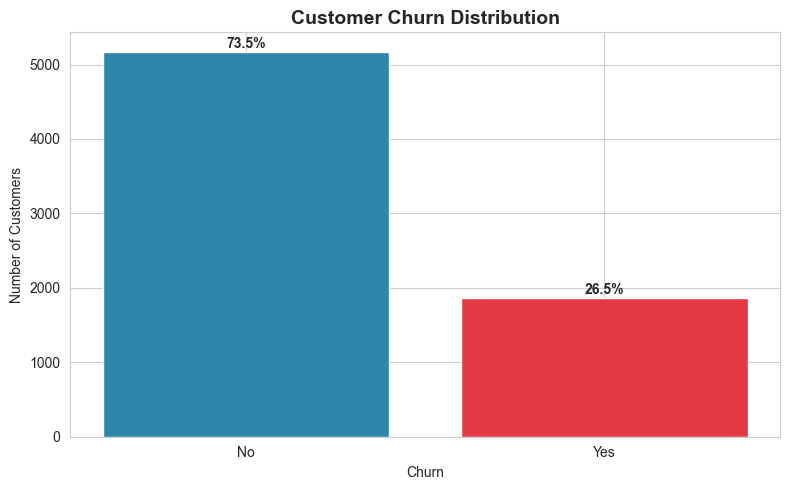

In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
bars = ax.bar(churn_counts.index, churn_counts.values, color=['#2E86AB', '#E63946'])
ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')

for bar, pct in zip(bars, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{pct:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/Dell/Desktop/churn-customer-diagnosis/reports/1_churn_distribution.png', dpi=150)
plt.show()

### Does Contract type relate to churn?

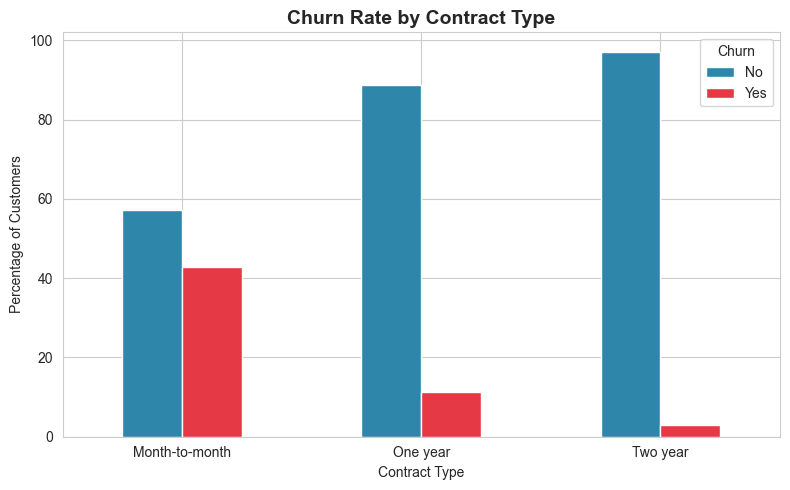

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


In [9]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

fig, ax = plt.subplots()
contract_churn.plot(kind='bar', stacked=False, ax=ax, color=['#2E86AB', '#E63946'])
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Percentage of Customers')
ax.legend(title='Churn')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('C:/Users/Dell/Desktop/churn-customer-diagnosis/reports/2_churn_by_contract.png', dpi=150)
plt.show()
print(contract_churn.round(1))

###  Does tenure how long they've been a customer relate to churn?


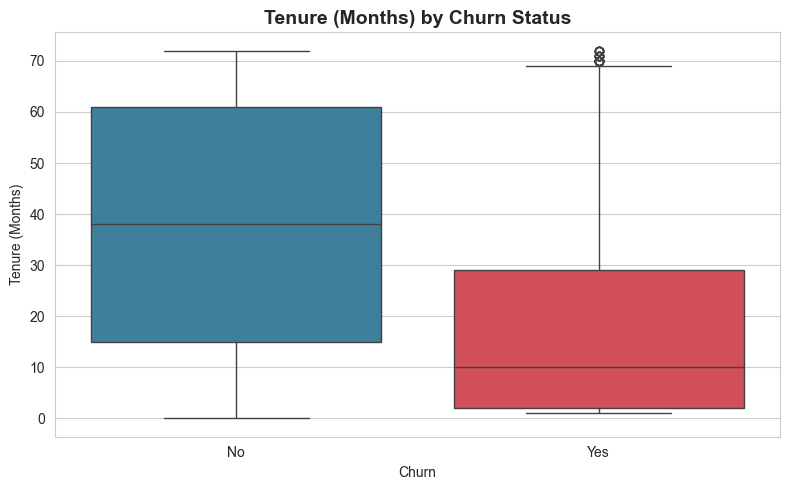

        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


In [15]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Churn', y='tenure',hue='Churn', ax=ax, palette=['#2E86AB', '#E63946'])
ax.set_title('Tenure (Months) by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Tenure (Months)')
plt.tight_layout()
plt.savefig('C:/Users/Dell/Desktop/churn-customer-diagnosis/reports/3_tenure_by_churn.png', dpi=150)
plt.show()
print(df.groupby('Churn')['tenure'].describe())

### Does Monthly Charges relate to churn?

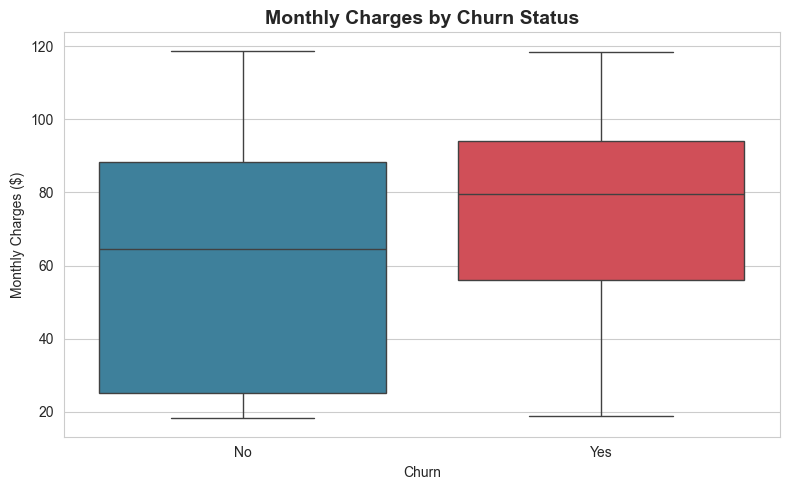

        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


In [20]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',hue='Churn', ax=ax, palette=['#2E86AB', '#E63946'])
ax.set_title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('C:/Users/Dell/Desktop/churn-customer-diagnosis/reports/04_charges_by_churn.png', dpi=150)
plt.show()
print(df.groupby('Churn')['MonthlyCharges'].describe())

### Internet Service type vs churn

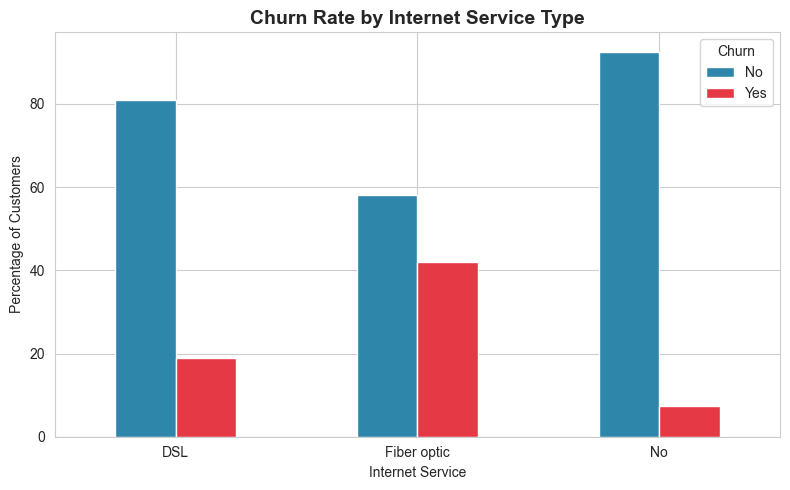

Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.6   7.4


In [21]:
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
fig, ax = plt.subplots()
internet_churn.plot(kind='bar', ax=ax, color=['#2E86AB', '#E63946'])
ax.set_title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Percentage of Customers')
ax.legend(title='Churn')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('C:/Users/Dell/Desktop/churn-customer-diagnosis/reports/05_churn_by_internet.png', dpi=150)
plt.show()
print(internet_churn.round(1))